# EESD Visual Analysis — Speculative Decoding for Hindi

Comprehensive visual analysis of all 12 methods and ablation studies.

**Data**: Best results consolidated across all experiment runs in `outputs_notebooks_backup/outputs/`.
For each method, the run with the highest acceptance rate (α) is selected, with speedup as tiebreaker. All metrics for a method come from the **same run** to preserve dependency.

In [121]:
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 13,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 17,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

C = {'autoregressive':'#6c757d','draft_model':'#e76f51','eesd_heavy_hook':'#2a9d8f',
     'eesd_heavy_true_exit':'#264653','eesd_bottleneck_true_exit':'#e9c46a',
     'eesd_thompson':'#f4a261','eesd_thompson_bottleneck':'#d62828',
     'eesd_entropy_exit':'#7209b7','eesd_ucb_bottleneck':'#3a86a7',
     'eesd_ucb_hook':'#06d6a0','eesd_weighted_thompson_bottleneck':'#fb8500',
     'eesd_weighted_thompson_hook':'#8338ec'}

SN = {'autoregressive':'AR','draft_model':'Draft','eesd_heavy_hook':'Hook',
      'eesd_heavy_true_exit':'TrueExit','eesd_bottleneck_true_exit':'BN-TrueExit',
      'eesd_thompson':'Thompson','eesd_thompson_bottleneck':'Thomp-BN',
      'eesd_entropy_exit':'Entropy','eesd_ucb_bottleneck':'UCB-BN',
      'eesd_ucb_hook':'UCB-Hook','eesd_weighted_thompson_bottleneck':'WThomp-BN',
      'eesd_weighted_thompson_hook':'WThomp-Hook'}

results_root = Path('outputs_notebooks_backup/outputs')
run_files = sorted(results_root.glob('**/ablation_results.json'))
if not run_files:
    raise FileNotFoundError(f'No ablation_results.json files found under {results_root}')

runs = []
for run_file in run_files:
    with run_file.open('r', encoding='utf-8') as f:
        payload = json.load(f)
    runs.append({
        'file': run_file,
        'folder': str(run_file.parent.relative_to(results_root)),
        'payload': payload,
    })

available_folders = sorted({r['folder'] for r in runs})

# Optional manual selection controls: set folders for specific methods.
# Folder names must match one of `available_folders` printed below.
DEFAULT_METHOD_FOLDER = None
FOLDER_BY_METHOD = {
    'autoregressive': 'outputs-after _UCB_v4/outputs',
    'draft_model': 'outputs-after _UCB_v5/outputs',
    'eesd_heavy_hook': 'outputs-after _UCB_v5/outputs',
    'eesd_heavy_true_exit': 'outputs_v3/outputs',
    'eesd_bottleneck_true_exit': 'outputs-after _UCB_v5/outputs',
    'eesd_thompson': 'outputs_v2/outputs',
    'eesd_thompson_bottleneck': 'outputs-after _UCB_v4/outputs',
    'eesd_entropy_exit': 'outputs-after _UCB_v4/outputs',
    'eesd_ucb_bottleneck': 'outputs-after _UCB_v5/outputs',
    'eesd_ucb_hook': 'outputs-after _UCB_v5/outputs',
    'eesd_weighted_thompson_bottleneck': 'outputs_AFTER_WT_V6/outputs',
    'eesd_weighted_thompson_hook': 'outputs_AFTER_WT_V6/outputs',
}

# Use the largest complete run as reference for non-method analyses.
ref_run = max(
    runs,
    key=lambda r: (
        r['payload'].get('autoregressive', {}).get('total_tokens', 0),
        sum(1 for v in r['payload'].values() if isinstance(v, dict) and v.get('method') and not v.get('skipped'))
    )
)
ref_file, ref_payload = ref_run['file'], ref_run['payload']
data = dict(ref_payload)

def _is_valid_method_record(method, record):
    return isinstance(record, dict) and not record.get('skipped') and record.get('method') == method

def _record_score(record):
    has_alpha = 1 if 'alpha' in record else 0
    alpha = float(record.get('alpha', -1.0)) if has_alpha else -1.0
    speedup = float(record.get('speedup', 0.0))
    return (has_alpha, alpha, speedup)

selected_from = {}
selected_mode = {}

for method in SN:
    manual_folder = FOLDER_BY_METHOD.get(method, DEFAULT_METHOD_FOLDER)
    chosen = None

    if manual_folder is not None:
        if manual_folder not in available_folders:
            print(f'[WARN] {SN[method]}: folder "{manual_folder}" not found. Falling back to auto.')
        else:
            for r in runs:
                record = r['payload'].get(method)
                if r['folder'] == manual_folder and _is_valid_method_record(method, record):
                    chosen = {'record': record, 'folder': r['folder'], 'file': r['file'], 'mode': 'manual'}
                    break
            if chosen is None:
                print(f'[WARN] {SN[method]}: no valid record in "{manual_folder}". Falling back to auto.')

    if chosen is None:
        candidates = []
        for r in runs:
            record = r['payload'].get(method)
            if _is_valid_method_record(method, record):
                candidates.append((_record_score(record), r['folder'], r['file'], record))
        if not candidates:
            continue
        _, best_folder, best_file, best_record = max(candidates, key=lambda x: x[0])
        chosen = {'record': best_record, 'folder': best_folder, 'file': best_file, 'mode': 'auto'}

    data[method] = chosen['record']
    selected_from[method] = str(chosen['file'].relative_to(results_root))
    selected_mode[method] = chosen['mode']

# Keep latency breakdown aligned with the selected per-method records.
latency = {}
for method in SN:
    record = data.get(method, {})
    if all(k in record for k in ('draft_time', 'verify_time', 'overhead_time')):
        latency[method] = {
            'draft_time': record['draft_time'],
            'verify_time': record['verify_time'],
            'overhead_time': record['overhead_time'],
        }
data['latency_breakdown'] = latency

# Save resolved consolidated results for reproducibility.
out_file = results_root / 'best_consolidated_results.json'
with out_file.open('w', encoding='utf-8') as f:
    json.dump(data, f, indent=2, ensure_ascii=False)

SKIP = {'cross_lingual','morphological_analysis','losslessness','k_ablation',
        'prompt_length_ablation','latency_breakdown'}
MK = [k for k in SN if k in data and k not in SKIP]
AK = [k for k in MK if 'alpha' in data[k]]
morph = data.get('morphological_analysis', {})

print(f'Loaded {len(run_files)} runs from {results_root}')
print(f'Available folders: {available_folders}')
print(f'Reference run for auxiliary analyses: {ref_file.relative_to(results_root)}')
print(f'{len(MK)} methods consolidated: {[SN[k] for k in MK]}')
print('Selected run per method (dependency-preserving):')
for k in MK:
    print(
        f'  {SN[k]:<12} <- {selected_from.get(k, "N/A")} '
        f'[{selected_mode.get(k, "auto")}] | α={data[k].get("alpha", "—")} speedup={data[k].get("speedup", "—")}'
    )

Loaded 6 runs from outputs_notebooks_backup/outputs
Available folders: ['outputs-after _UCB_v4/outputs', 'outputs-after _UCB_v5/outputs', 'outputs_500_prompts/outputs', 'outputs_AFTER_WT_V6/outputs', 'outputs_v2/outputs', 'outputs_v3/outputs']
Reference run for auxiliary analyses: outputs_500_prompts/outputs/ablation_results.json
12 methods consolidated: ['AR', 'Draft', 'Hook', 'TrueExit', 'BN-TrueExit', 'Thompson', 'Thomp-BN', 'Entropy', 'UCB-BN', 'UCB-Hook', 'WThomp-BN', 'WThomp-Hook']
Selected run per method (dependency-preserving):
  AR           <- outputs-after _UCB_v4/outputs/ablation_results.json [manual] | α=— speedup=1.0
  Draft        <- outputs-after _UCB_v5/outputs/ablation_results.json [manual] | α=0.6518 speedup=0.707
  Hook         <- outputs-after _UCB_v5/outputs/ablation_results.json [manual] | α=0.4687 speedup=0.552
  TrueExit     <- outputs_v3/outputs/ablation_results.json [manual] | α=0.6087 speedup=0.736
  BN-TrueExit  <- outputs-after _UCB_v5/outputs/ablation_res

---
## 1. Acceptance Rate (α) — All Methods

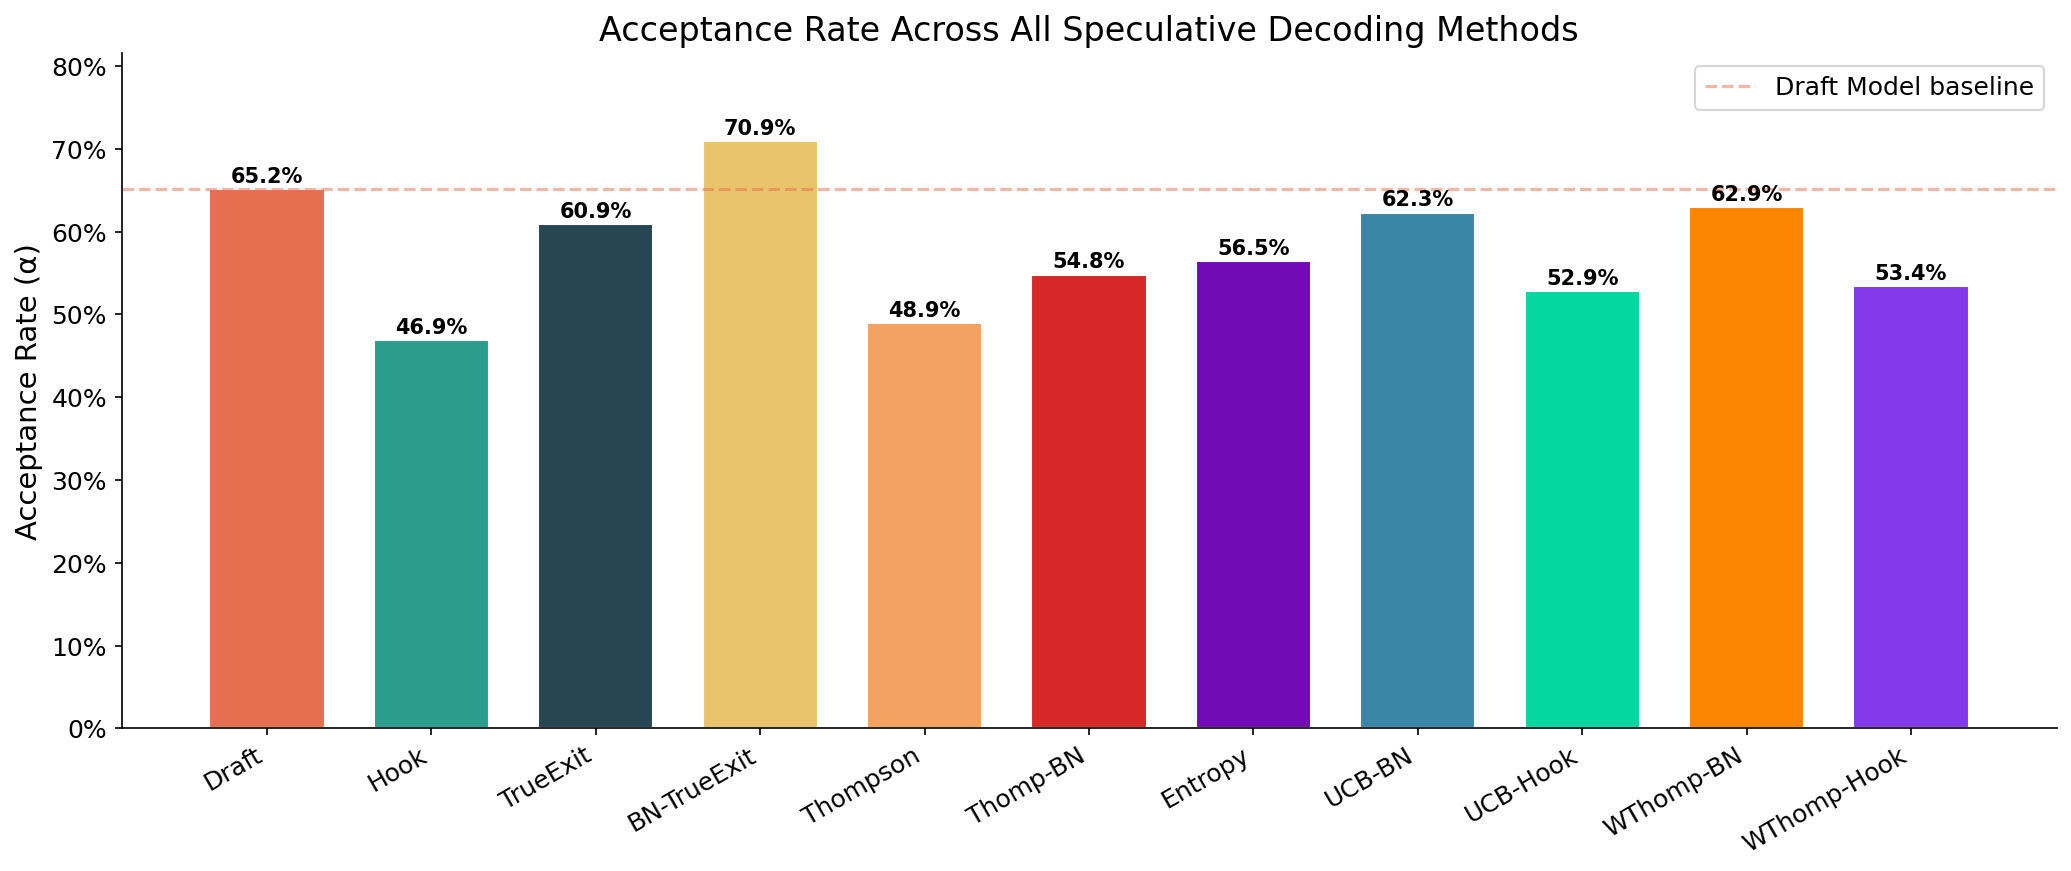

In [122]:
fig, ax = plt.subplots(figsize=(14, 6))
names = [SN[k] for k in AK]; alphas = [data[k]['alpha'] for k in AK]
bars = ax.bar(names, alphas, color=[C[k] for k in AK], edgecolor='white', width=0.7)
for b, a in zip(bars, alphas):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.008, f'{a:.1%}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Acceptance Rate (α)')
ax.set_title('Acceptance Rate Across All Speculative Decoding Methods')
ax.set_ylim(0, max(alphas)*1.15)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.axhline(data['draft_model']['alpha'], color=C['draft_model'], ls='--', alpha=0.5, label='Draft Model baseline')
ax.legend(); plt.xticks(rotation=30, ha='right'); plt.tight_layout()
plt.savefig('outputs_AFTER_WT_V6/outputs/fig01_acceptance_rate.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 2. Speedup Comparison — All Methods

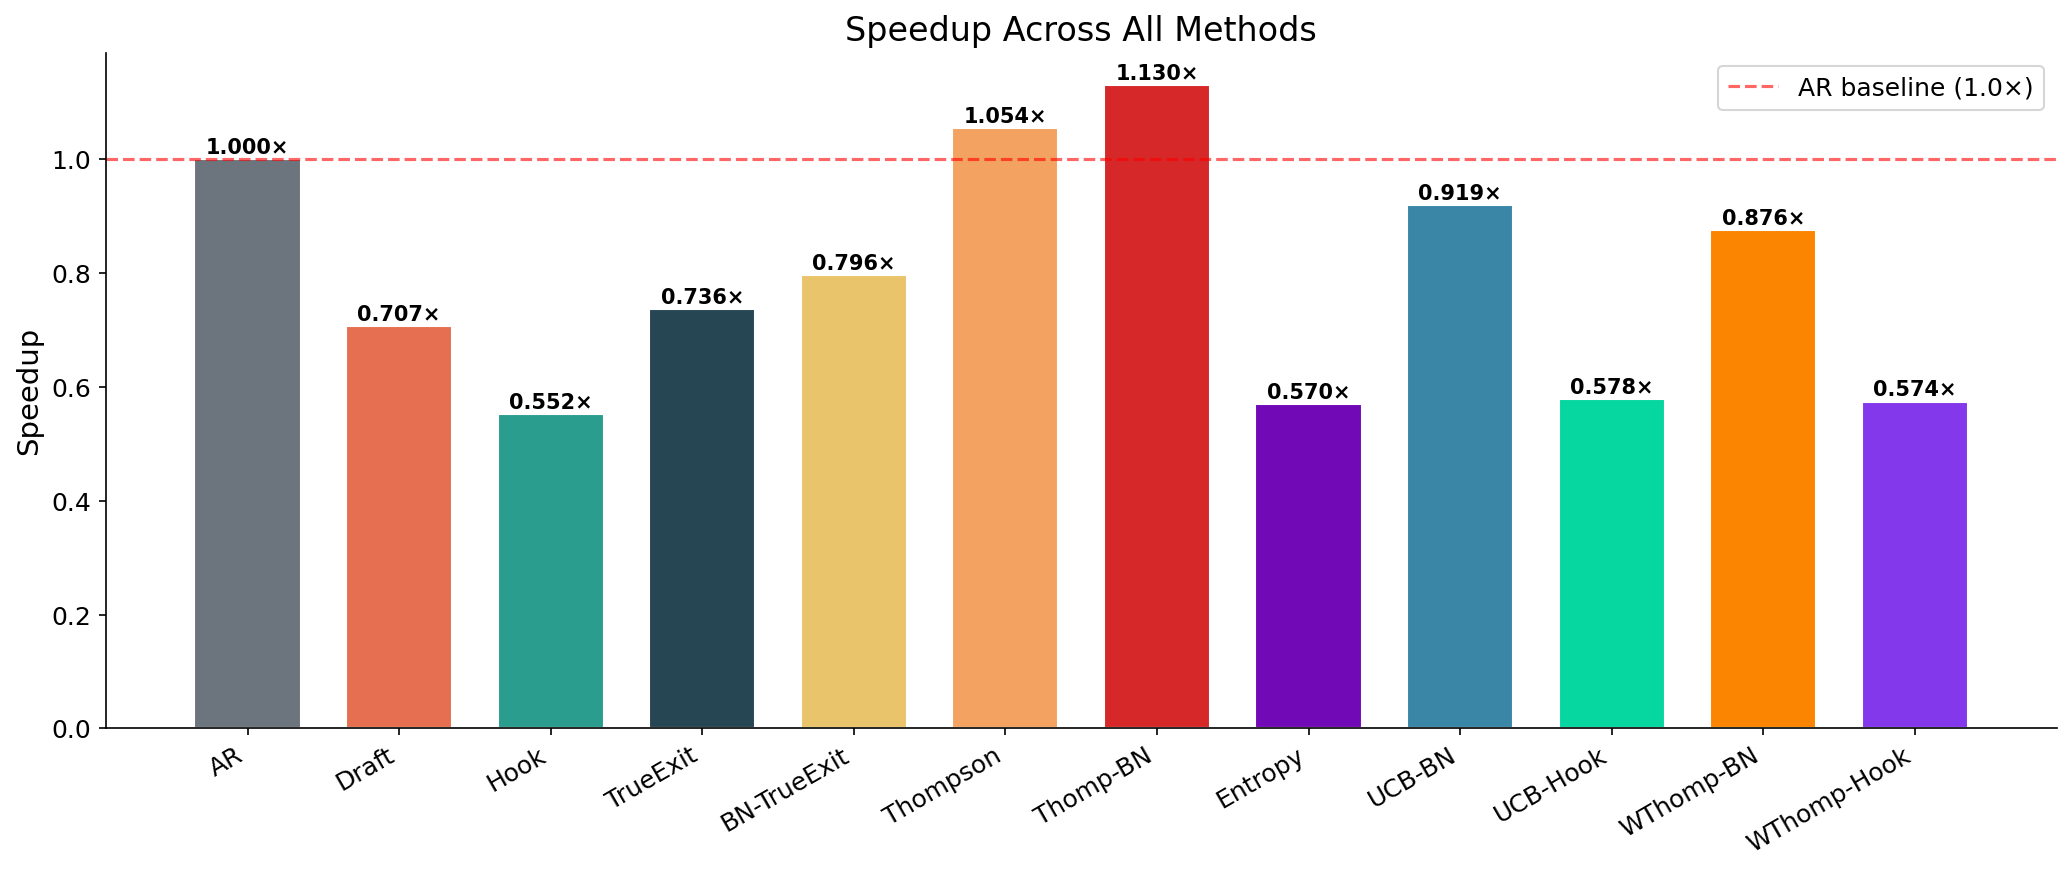

In [123]:
fig, ax = plt.subplots(figsize=(14, 6))
names = [SN[k] for k in MK]; speedups = [data[k].get('speedup', 1.0) for k in MK]
bars = ax.bar(names, speedups, color=[C[k] for k in MK], edgecolor='white', width=0.7)
for b, s in zip(bars, speedups):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{s:.3f}×',
            ha='center', fontsize=10, fontweight='bold')
ax.axhline(1.0, color='red', ls='--', alpha=0.6, label='AR baseline (1.0×)')
ax.set_ylabel('Speedup'); ax.set_title('Speedup Across All Methods')
ax.legend(); plt.xticks(rotation=30, ha='right'); plt.tight_layout()
plt.savefig('outputs_AFTER_WT_V6/outputs/fig02_speedup.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 3. α vs Speedup — Trade-off Scatter

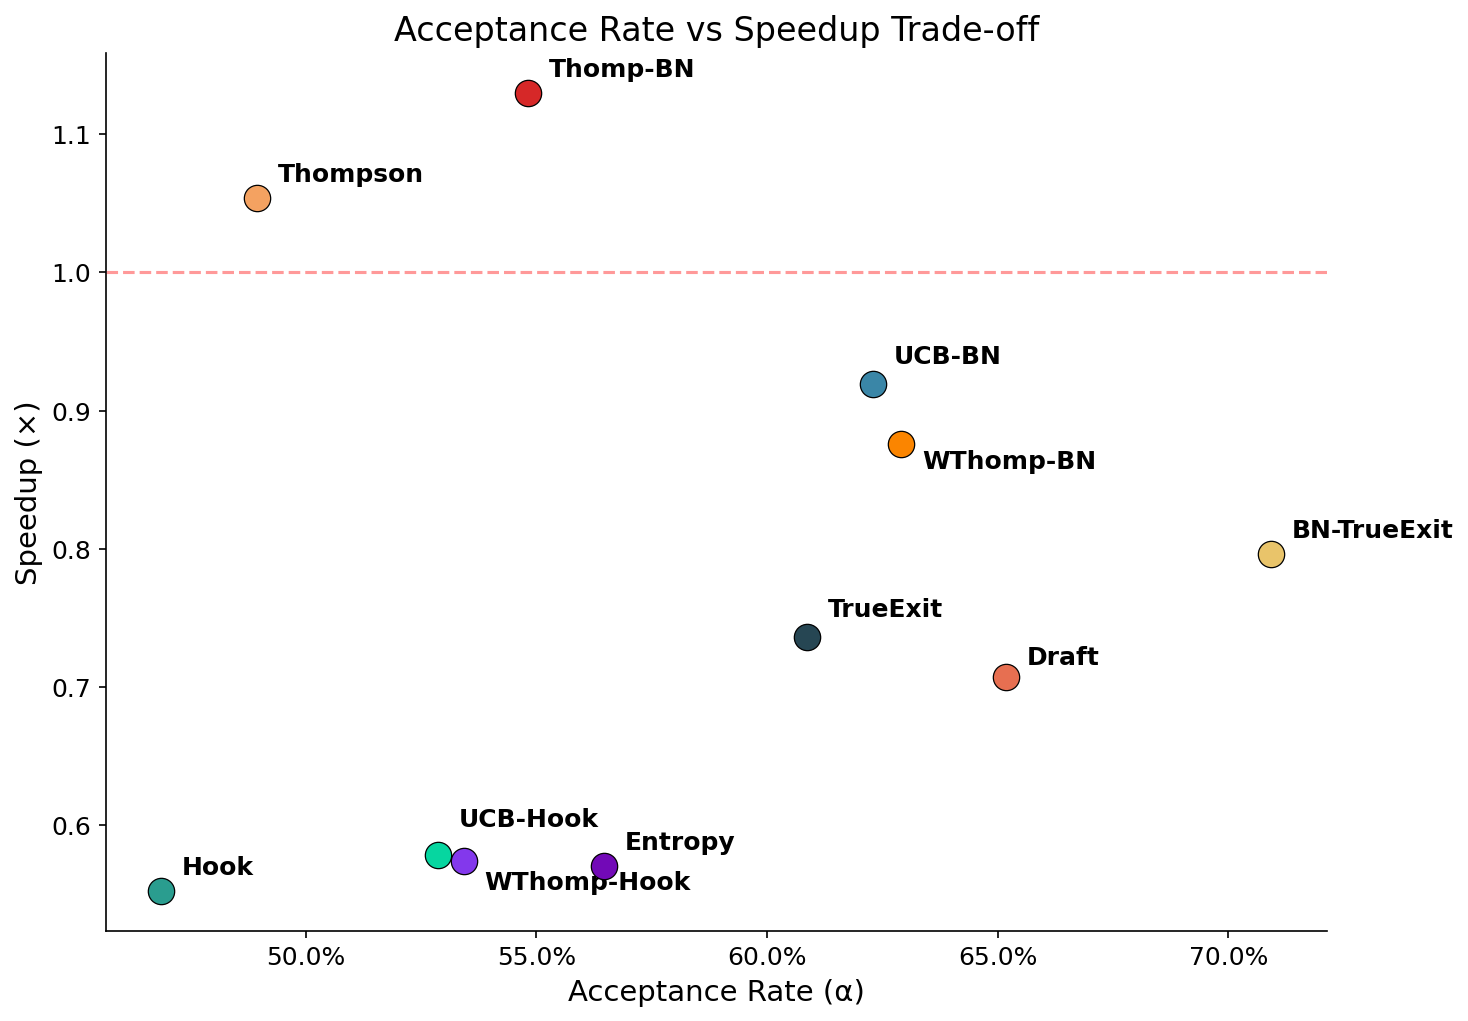

In [124]:
fig, ax = plt.subplots(figsize=(10, 7))

# Hand-tuned offsets to avoid overlapping labels in dense regions.
label_offsets = {
    'eesd_ucb_hook': (10, 14),
    'eesd_weighted_thompson_hook': (10, -14),
    'eesd_ucb_bottleneck': (10, 10),
    'eesd_weighted_thompson_bottleneck': (10, -12),
    'eesd_heavy_true_exit': (10, 10),
    'draft_model': (10, 6),
}

for k in AK:
    x = data[k]['alpha']
    y = data[k]['speedup']
    ax.scatter(x, y, s=160, c=C[k], edgecolors='black', linewidths=0.6, zorder=5)
    dx, dy = label_offsets.get(k, (10, 8))
    ax.annotate(
        SN[k],
        (x, y),
        textcoords='offset points',
        xytext=(dx, dy),
        fontsize=12,
        fontweight='semibold',
        bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.65, edgecolor='none')
    )

ax.axhline(1.0, color='red', ls='--', alpha=0.4, label='AR baseline')
ax.set_xlabel('Acceptance Rate (α)')
ax.set_ylabel('Speedup (×)')
ax.set_title('Acceptance Rate vs Speedup Trade-off')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig('outputs_AFTER_WT_V6/outputs/fig03_alpha_vs_speedup.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 5. Per-Depth Acceptance Rate Heatmap

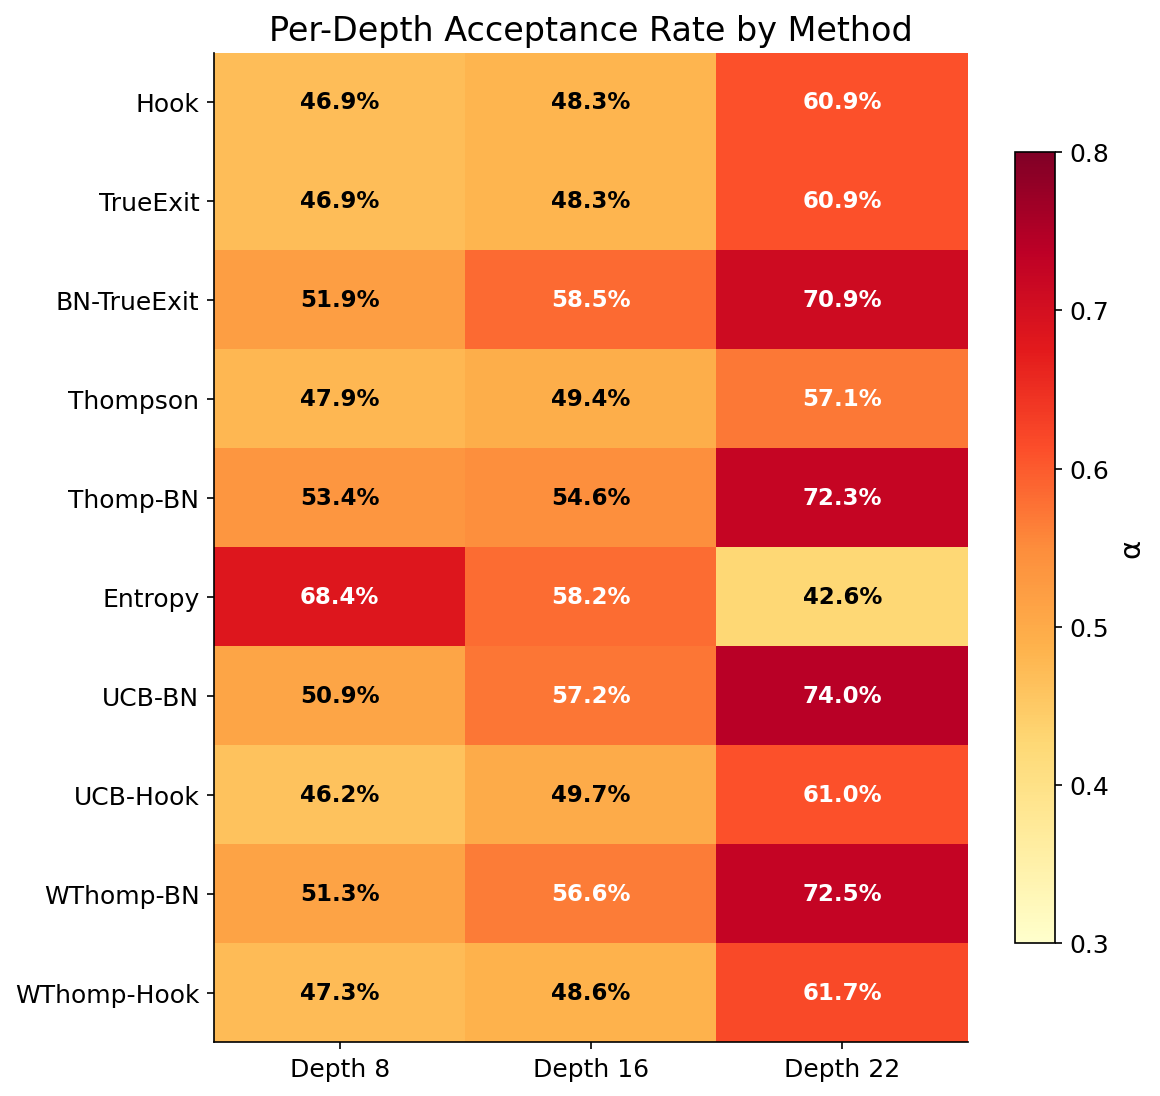

In [125]:
dm = [k for k in MK if 'per_depth_alpha' in data[k]
      and any(d in data[k]['per_depth_alpha'] for d in ['8','16','22'])]
depths = ['8','16','22']
matrix = np.array([[data[k]['per_depth_alpha'].get(d, 0) for d in depths] for k in dm])
ylabels = [SN[k] for k in dm]
fig, ax = plt.subplots(figsize=(8, len(dm)*0.6+1.5))
im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto', vmin=0.3, vmax=0.8)
ax.set_xticks(range(3)); ax.set_xticklabels(['Depth 8','Depth 16','Depth 22'])
ax.set_yticks(range(len(ylabels))); ax.set_yticklabels(ylabels)
for i in range(len(ylabels)):
    for j in range(3):
        ax.text(j, i, f'{matrix[i,j]:.1%}', ha='center', va='center', fontsize=11,
                fontweight='bold', color='white' if matrix[i,j]>0.55 else 'black')
plt.colorbar(im, ax=ax, label='α', shrink=0.8)
ax.set_title('Per-Depth Acceptance Rate by Method')
plt.tight_layout()
plt.savefig('outputs_AFTER_WT_V6/outputs/fig05_depth_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 6. Depth Usage — Adaptive Methods

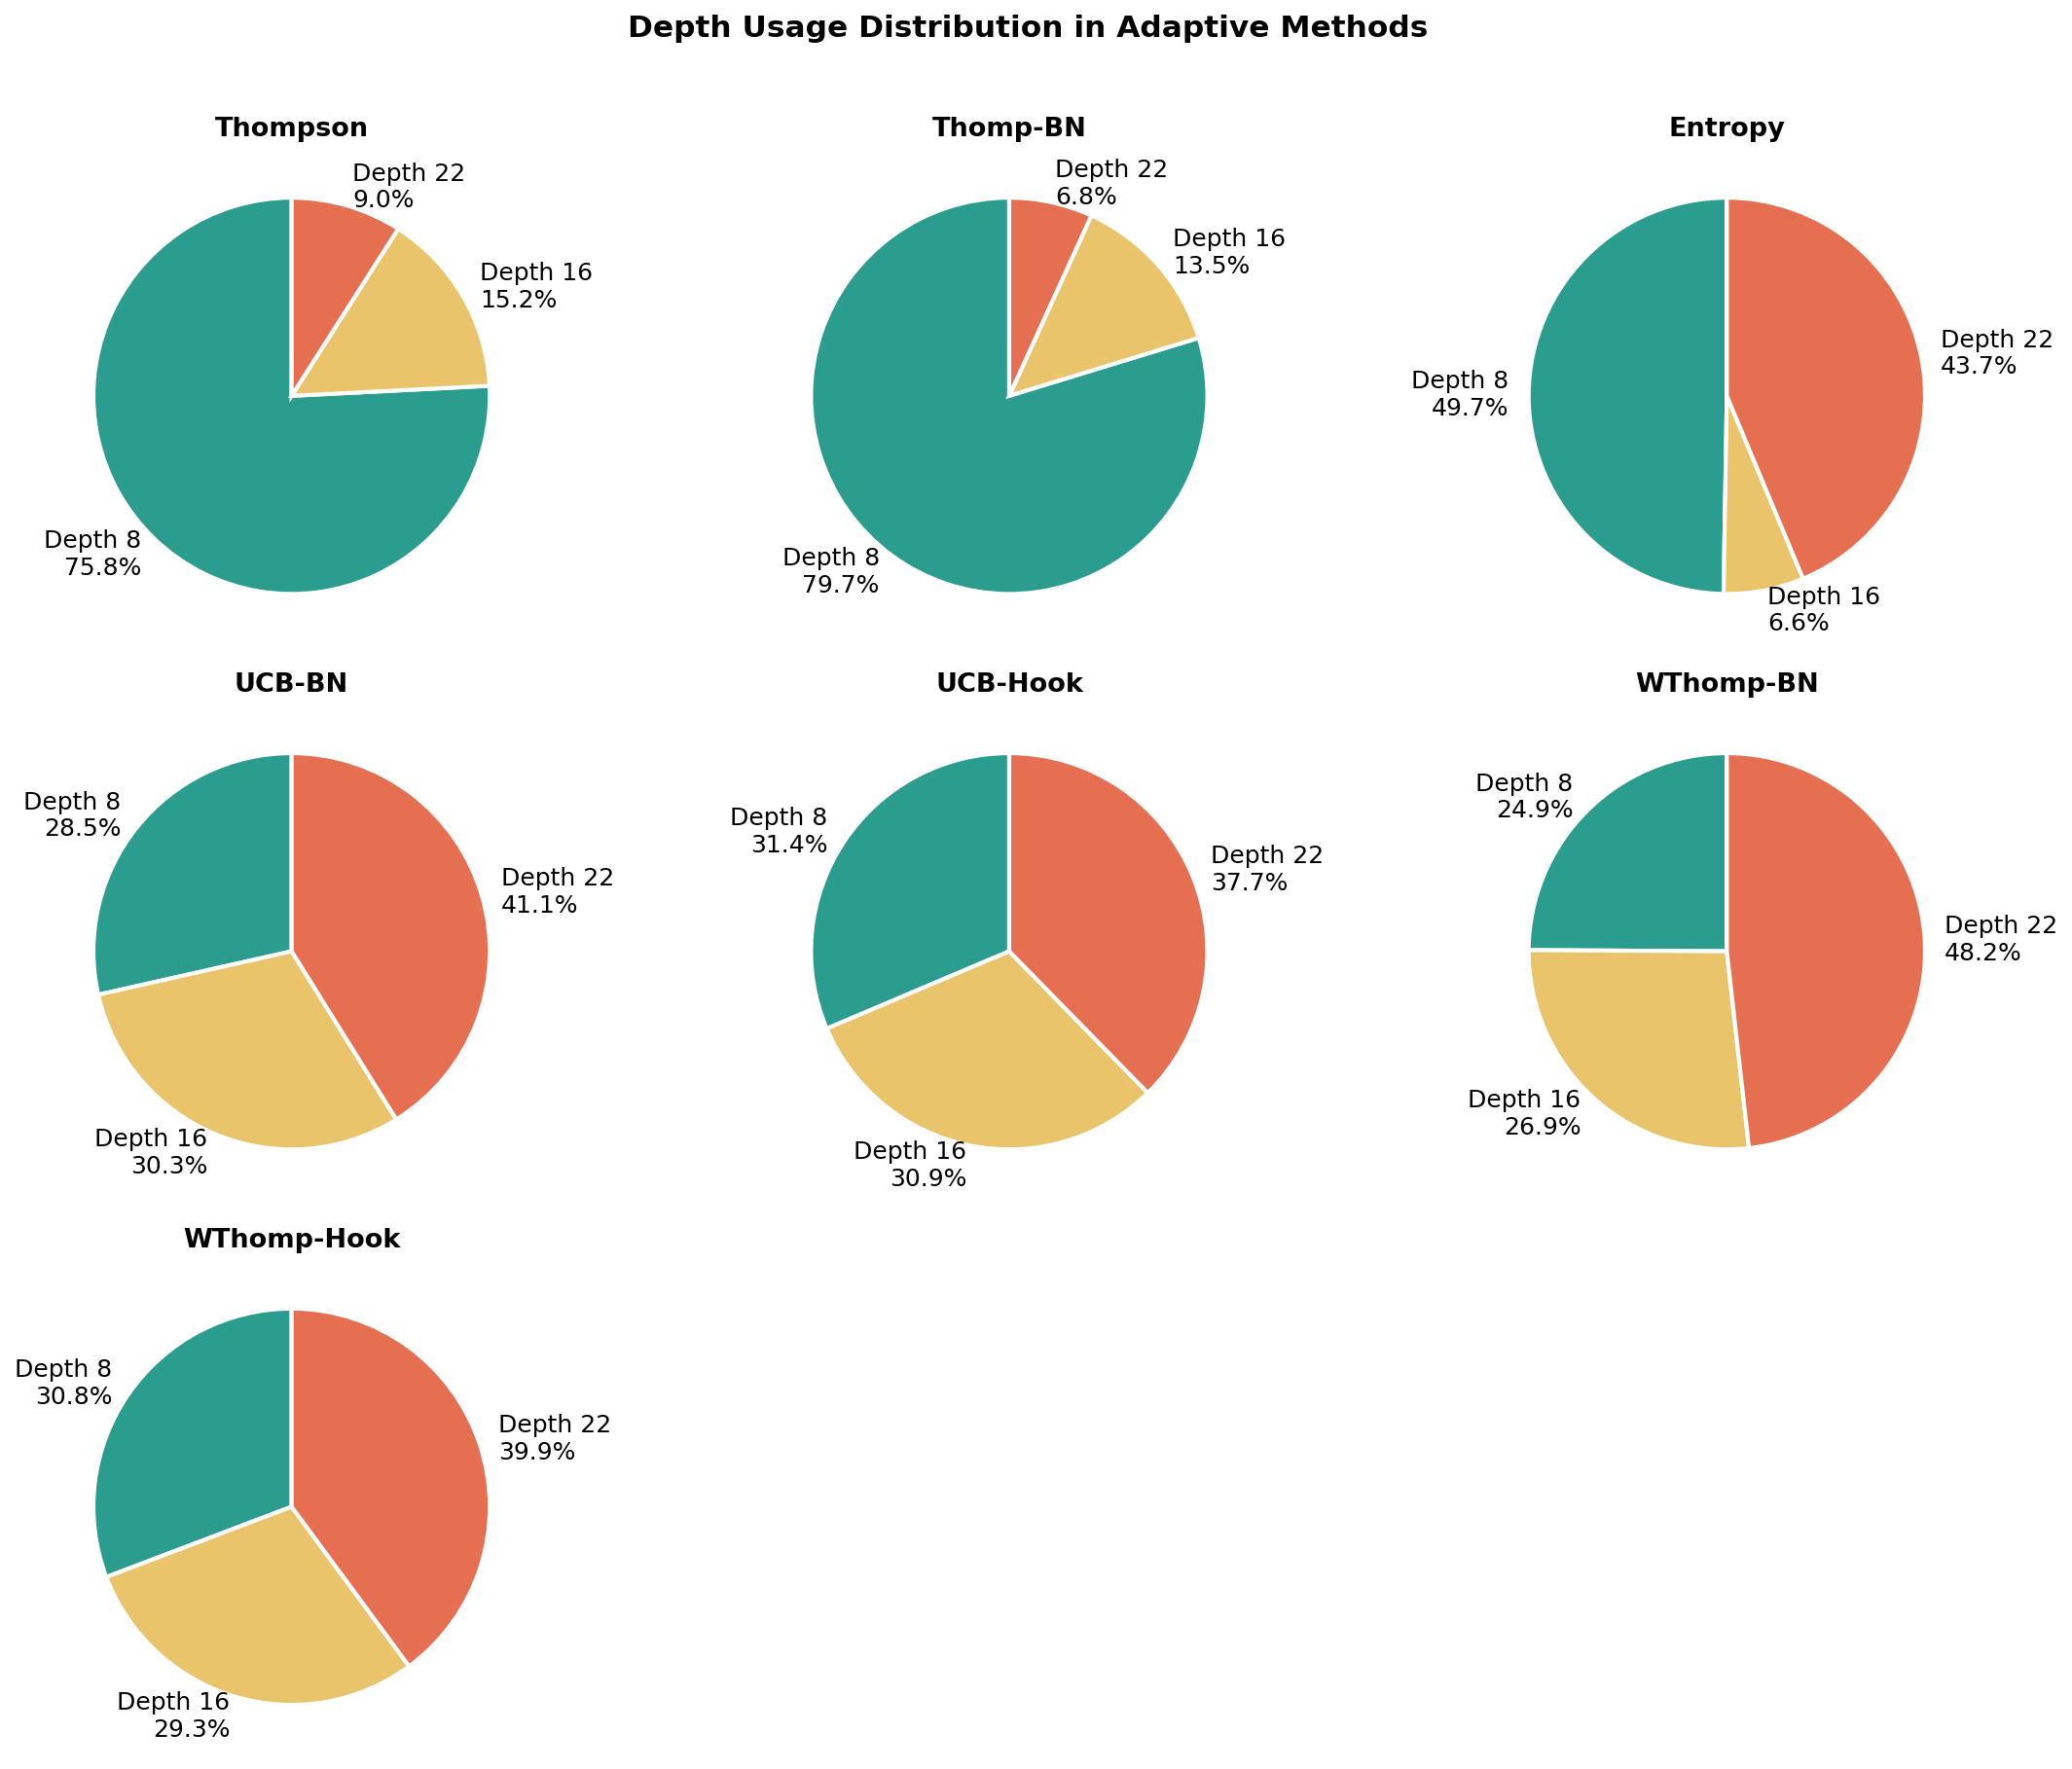

In [126]:
adaptive = [k for k in MK if 'depth_usage' in data[k]]
n = len(adaptive); ncols = min(3, n); nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes_flat = np.array(axes).flatten() if n > 1 else [axes]
colors_d = ['#2a9d8f','#e9c46a','#e76f51']
for i, k in enumerate(adaptive):
    usage = data[k]['depth_usage']; ds = list(usage.keys()); vs = list(usage.values())
    total = sum(vs); pcts = [v/total*100 for v in vs]
    axes_flat[i].pie(vs, labels=[f'Depth {d}\n{p:.1f}%' for d, p in zip(ds, pcts)],
                     colors=colors_d, startangle=90,
                     wedgeprops={'edgecolor':'white','linewidth':2})
    axes_flat[i].set_title(SN[k], fontsize=13, fontweight='bold')
for j in range(n, len(axes_flat)):
    axes_flat[j].set_visible(False)
fig.suptitle('Depth Usage Distribution in Adaptive Methods',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs_AFTER_WT_V6/outputs/fig06_depth_usage.png', dpi=200, bbox_inches='tight')
plt.show()

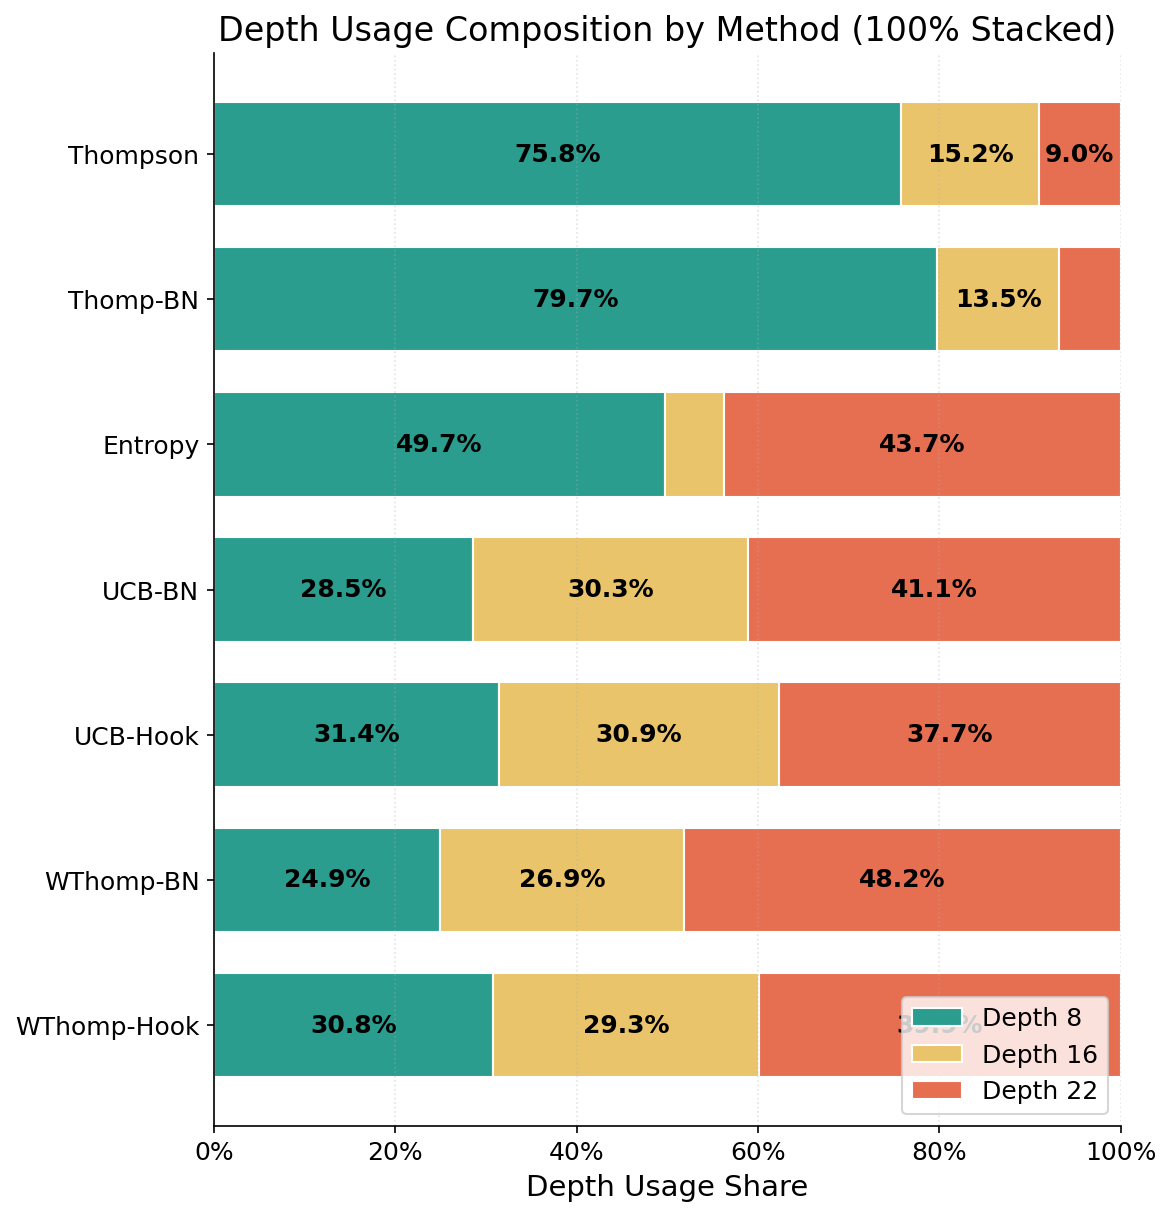

In [127]:
# Alternative depth-usage representations for easier cross-method comparison.
depth_labels = ['8', '16', '22']
adaptive_methods = [k for k in MK if 'depth_usage' in data[k]]
method_names = [SN[k] for k in adaptive_methods]

# Build a normalized matrix: rows=methods, cols=depths.
depth_matrix = []
for k in adaptive_methods:
    usage = data[k].get('depth_usage', {})
    vals = np.array([float(usage.get(d, 0.0)) for d in depth_labels], dtype=float)
    total = vals.sum()
    if total > 0:
        vals = vals / total
    depth_matrix.append(vals)

depth_matrix = np.array(depth_matrix)

# 1) 100% stacked horizontal bars (portrait layout to match Cell 10 style).
fig, ax = plt.subplots(figsize=(8, max(7.5, 0.9 * len(method_names) + 2.0)))
left = np.zeros(len(method_names))
depth_colors = {'8': '#2a9d8f', '16': '#e9c46a', '22': '#e76f51'}

for j, d in enumerate(depth_labels):
    vals = depth_matrix[:, j]
    bars = ax.barh(method_names, vals, left=left, color=depth_colors[d], edgecolor='white', height=0.72, label=f'Depth {d}')
    for i, (b, v) in enumerate(zip(bars, vals)):
        if v >= 0.08:
            ax.text(left[i] + v / 2, b.get_y() + b.get_height() / 2, f'{v:.1%}', ha='center', va='center', fontsize=12, fontweight='bold')
    left += vals

ax.set_xlim(0, 1.0)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel('Depth Usage Share')
ax.set_title('Depth Usage Composition by Method (100% Stacked)')
ax.grid(axis='x', linestyle=':', alpha=0.35)
ax.legend(loc='lower right', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('outputs_AFTER_WT_V6/outputs/fig06b_depth_usage_stacked.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 7. K-Ablation — α & Speedup vs Draft Length

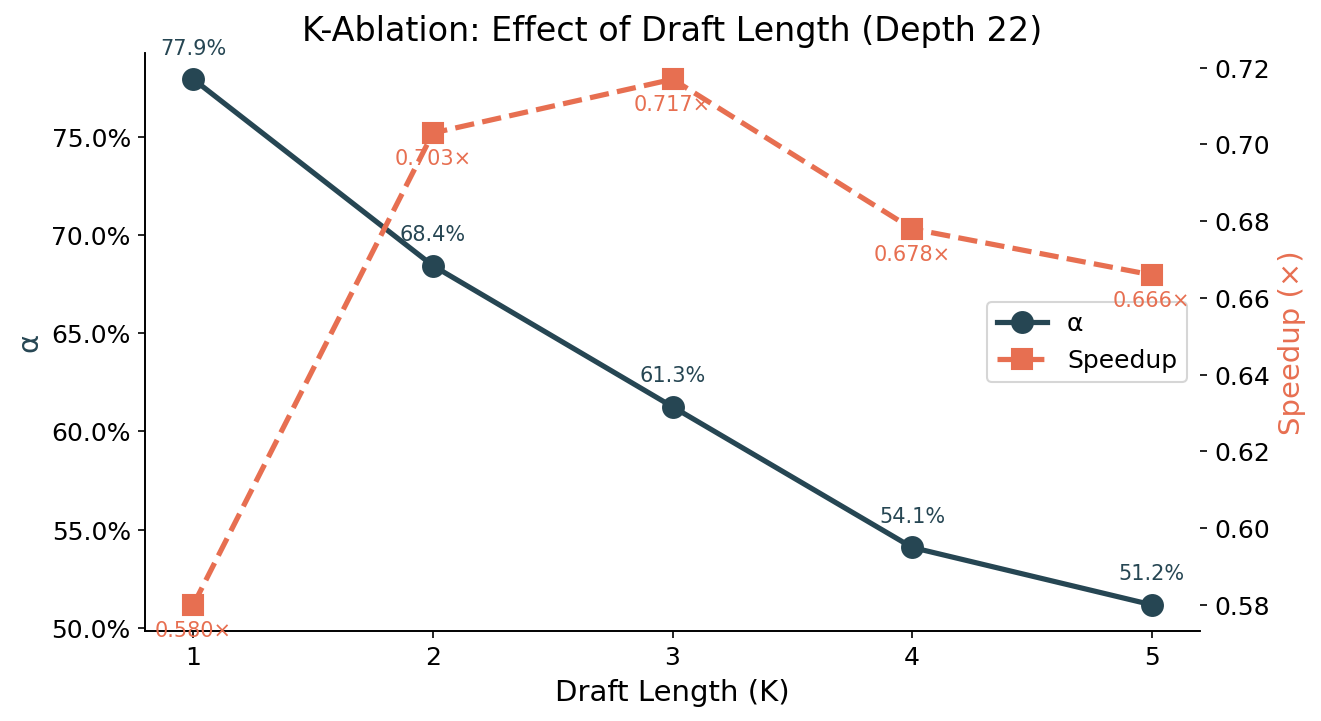

In [128]:
kd = data['k_ablation']; ks = sorted(kd.keys(), key=int)
ka = [kd[k]['alpha'] for k in ks]; ksp = [kd[k]['speedup'] for k in ks]
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot([int(k) for k in ks], ka, 'o-', color='#264653', lw=2.5, ms=10, label='α')
ax1.set_xlabel('Draft Length (K)'); ax1.set_ylabel('α', color='#264653')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2 = ax1.twinx()
ax2.plot([int(k) for k in ks], ksp, 's--', color='#e76f51', lw=2.5, ms=10, label='Speedup')
ax2.set_ylabel('Speedup (×)', color='#e76f51')
for kv, a, s in zip([int(k) for k in ks], ka, ksp):
    ax1.annotate(f'{a:.1%}', (kv,a), textcoords='offset points', xytext=(0,12),
                 fontsize=10, ha='center', color='#264653')
    ax2.annotate(f'{s:.3f}×', (kv,s), textcoords='offset points', xytext=(0,-15),
                 fontsize=10, ha='center', color='#e76f51')
h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='center right')
ax1.set_title('K-Ablation: Effect of Draft Length (Depth 22)')
ax1.set_xticks([int(k) for k in ks]); plt.tight_layout()
plt.savefig('outputs_AFTER_WT_V6/outputs/fig07_k_ablation.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 10. Morphological Analysis — Per-Category & Per-UPOS

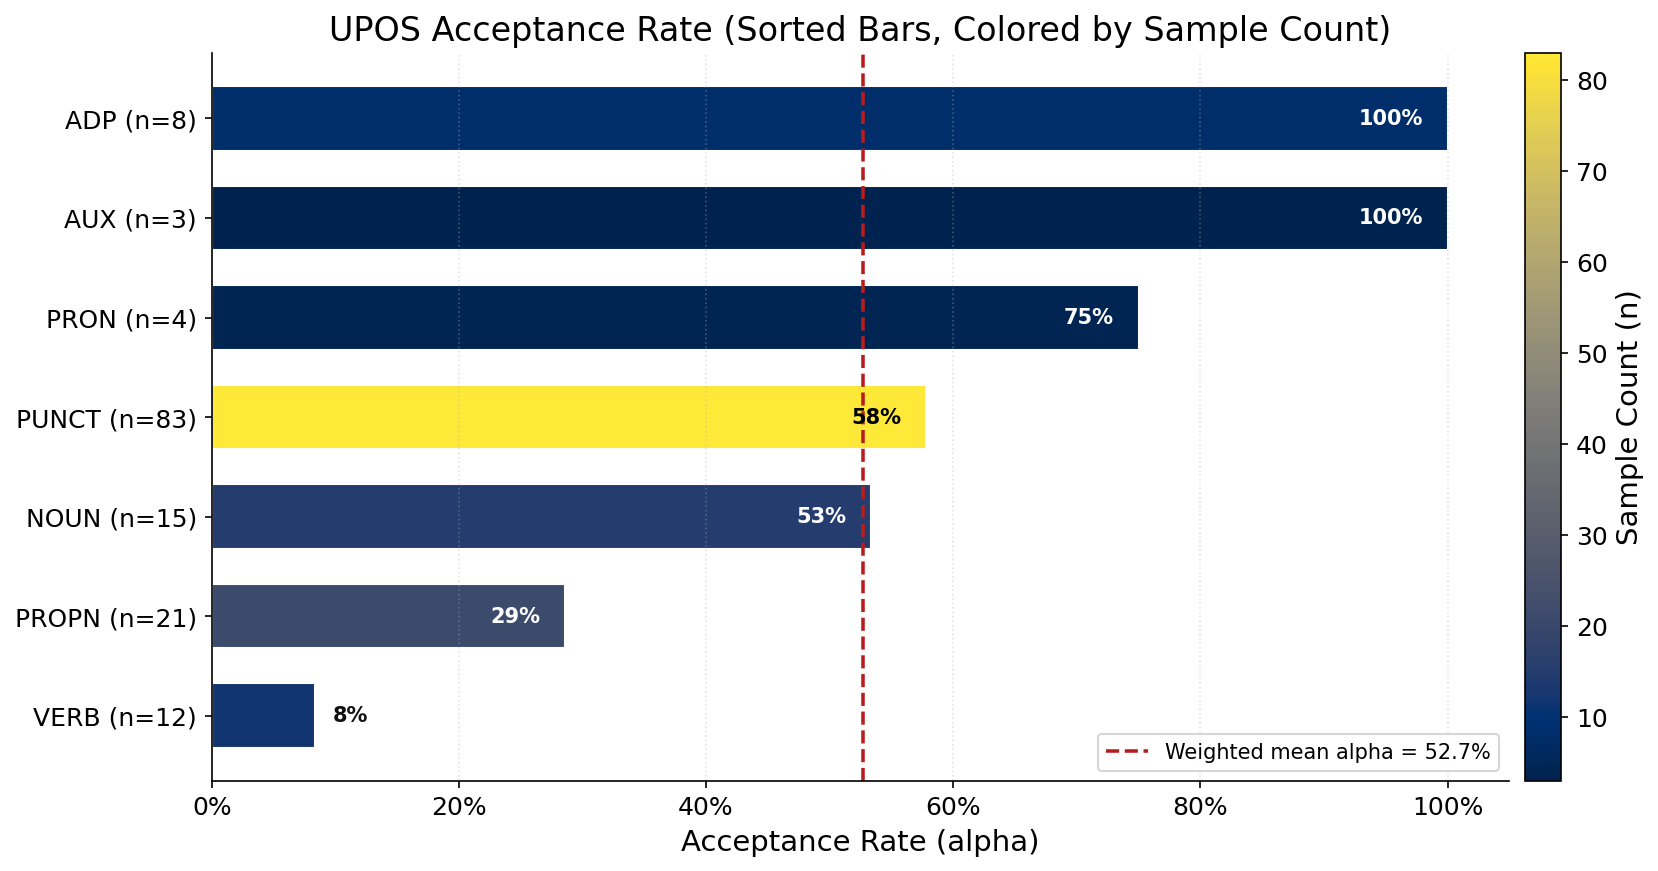

In [129]:
upos = morph.get('upos_distribution', {})
fig, ax = plt.subplots(figsize=(12, 6))

if upos:
    upos_df = pd.DataFrame([
        {'tag': tag, 'alpha': vals.get('alpha', 0.0), 'count': vals.get('count', 0)}
        for tag, vals in upos.items()
    ]).sort_values('alpha', ascending=False).reset_index(drop=True)

    # Remove sparse categories requested by user (n = 1).
    upos_df = upos_df[upos_df['count'] > 1].reset_index(drop=True)

    if not upos_df.empty:
        y = np.arange(len(upos_df))
        cmin = upos_df['count'].min()
        cmax = upos_df['count'].max()
        if cmin == cmax:
            cmax = cmin + 1
        norm = plt.Normalize(cmin, cmax)
        colors = plt.cm.cividis(norm(upos_df['count'].values))

        bars = ax.barh(y, upos_df['alpha'].values, color=colors, edgecolor='white', height=0.65)

        for i, (bar, alpha_val) in enumerate(zip(bars, upos_df['alpha'].values)):
            # Use contrast-aware text color when placing inside bars; place outside for tiny bars.
            x_text = alpha_val - 0.02
            ha = 'right'
            r, g, b, _ = bar.get_facecolor()
            luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
            text_color = 'black' if luminance > 0.6 else 'white'

            if alpha_val < 0.12:
                x_text = alpha_val + 0.015
                ha = 'left'
                text_color = '#111111'

            ax.text(x_text, i, f'{alpha_val:.0%}', va='center', ha=ha,
                    fontsize=10, fontweight='bold', color=text_color)

        weighted_alpha = np.average(
            upos_df['alpha'].values,
            weights=np.maximum(upos_df['count'].values, 1)
        )
        ax.axvline(
            weighted_alpha, color='#b91c1c', linestyle='--', linewidth=1.7,
            label=f'Weighted mean alpha = {weighted_alpha:.1%}'
        )

        ylabels = [f"{row['tag']} (n={int(row['count'])})" for _, row in upos_df.iterrows()]
        ax.set_yticks(y)
        ax.set_yticklabels(ylabels)
        ax.invert_yaxis()
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        ax.set_xlim(0, 1.05)
        ax.grid(axis='x', linestyle=':', alpha=0.35)
        ax.legend(loc='lower right', fontsize=10)

        sm = plt.cm.ScalarMappable(cmap='cividis', norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, pad=0.01)
        cbar.set_label('Sample Count (n)')
    else:
        ax.text(0.5, 0.5, 'No UPOS tags with n > 1 available for plotting',
                ha='center', va='center', transform=ax.transAxes)
else:
    ax.text(0.5, 0.5, 'No UPOS distribution data found', ha='center', va='center', transform=ax.transAxes)

ax.set_xlabel('Acceptance Rate (alpha)')
ax.set_title('UPOS Acceptance Rate (Sorted Bars, Colored by Sample Count)')
plt.tight_layout()
plt.savefig('outputs_AFTER_WT_V6/outputs/fig10_morphological.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 11. True Exit vs Hook — Per-Depth Time

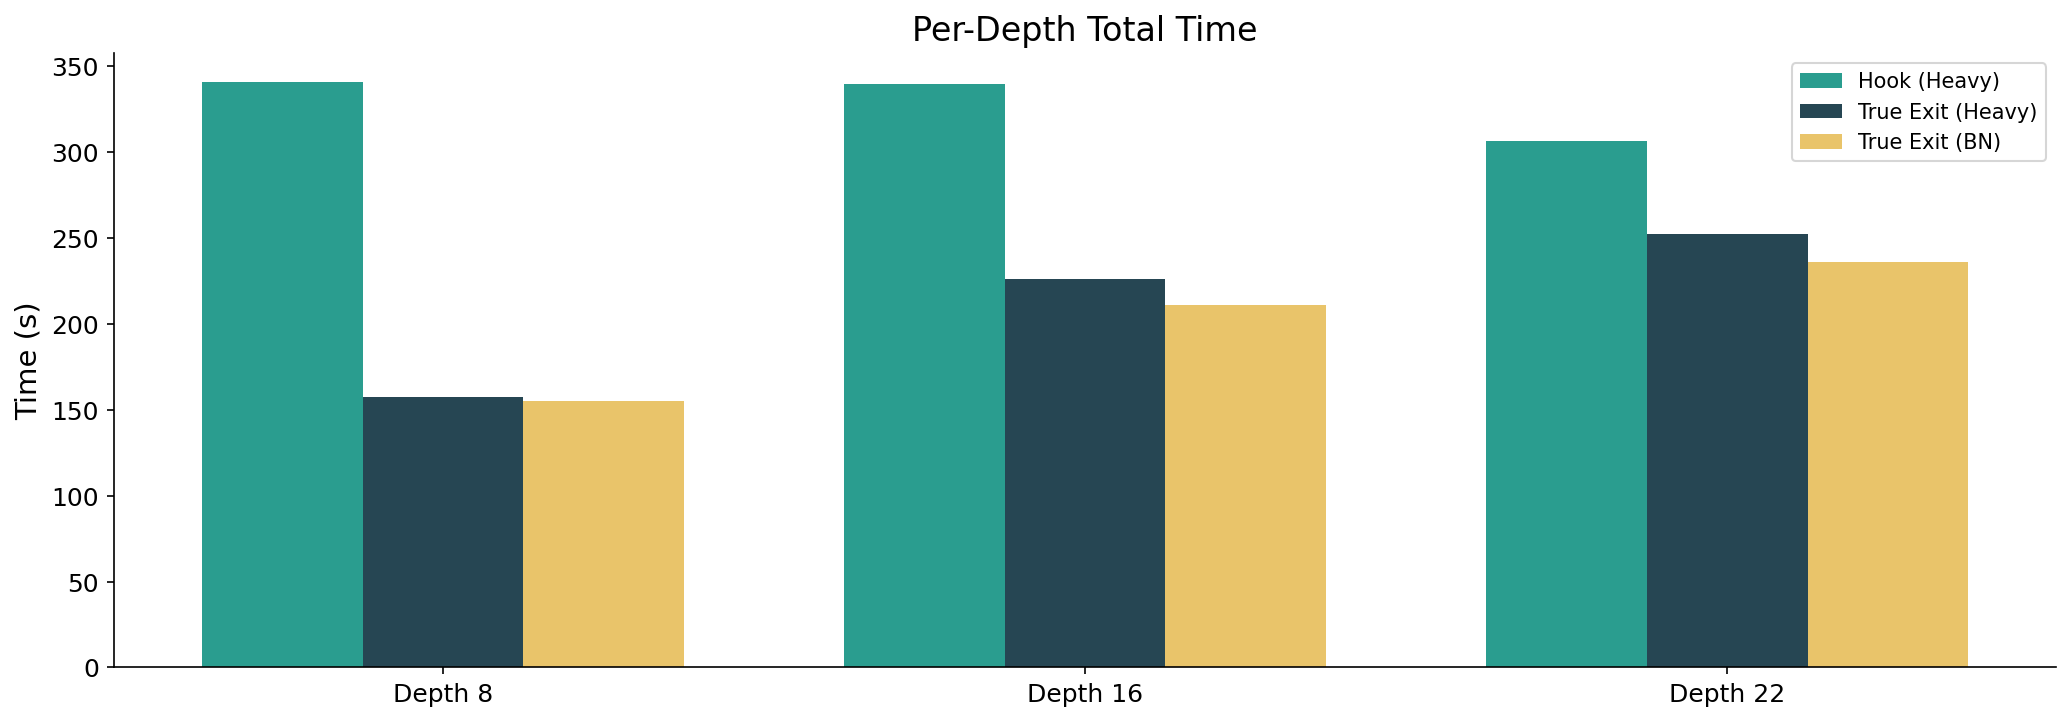

In [130]:
fig, ax = plt.subplots(figsize=(14, 5))
depths = ['8','16','22']
ht = [data['eesd_heavy_hook']['per_depth_time'][d] for d in depths]
tt = [data['eesd_heavy_true_exit']['per_depth_time'][d] for d in depths]
bt = [data['eesd_bottleneck_true_exit']['per_depth_time'][d] for d in depths]
x = np.arange(3); w = 0.25
ax.bar(x-w, ht, w, label='Hook (Heavy)', color='#2a9d8f')
ax.bar(x, tt, w, label='True Exit (Heavy)', color='#264653')
ax.bar(x+w, bt, w, label='True Exit (BN)', color='#e9c46a')
ax.set_ylabel('Time (s)'); ax.set_title('Per-Depth Total Time')
ax.set_xticks(x); ax.set_xticklabels([f'Depth {d}' for d in depths])
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 12. 500-Sample Output Plot

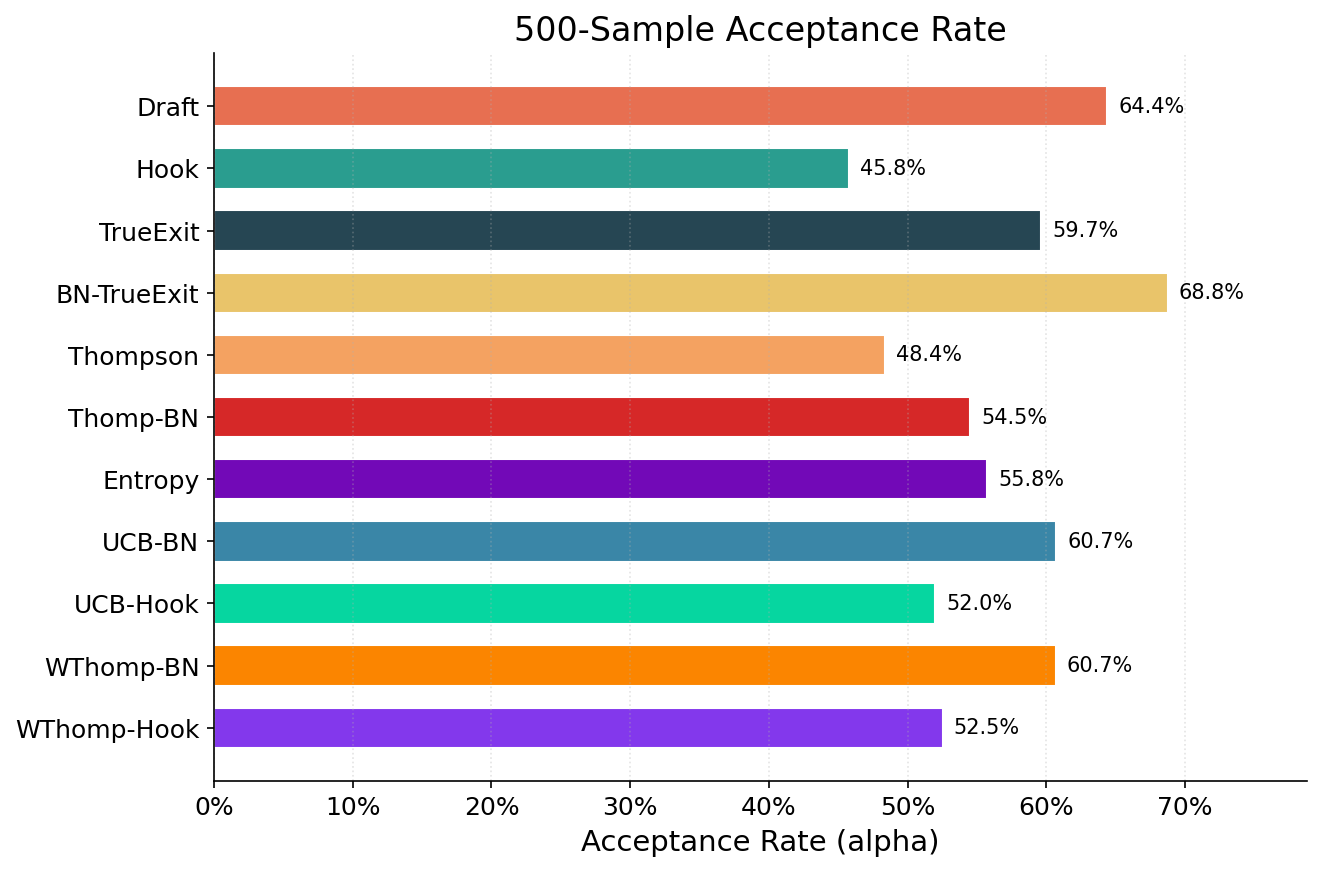

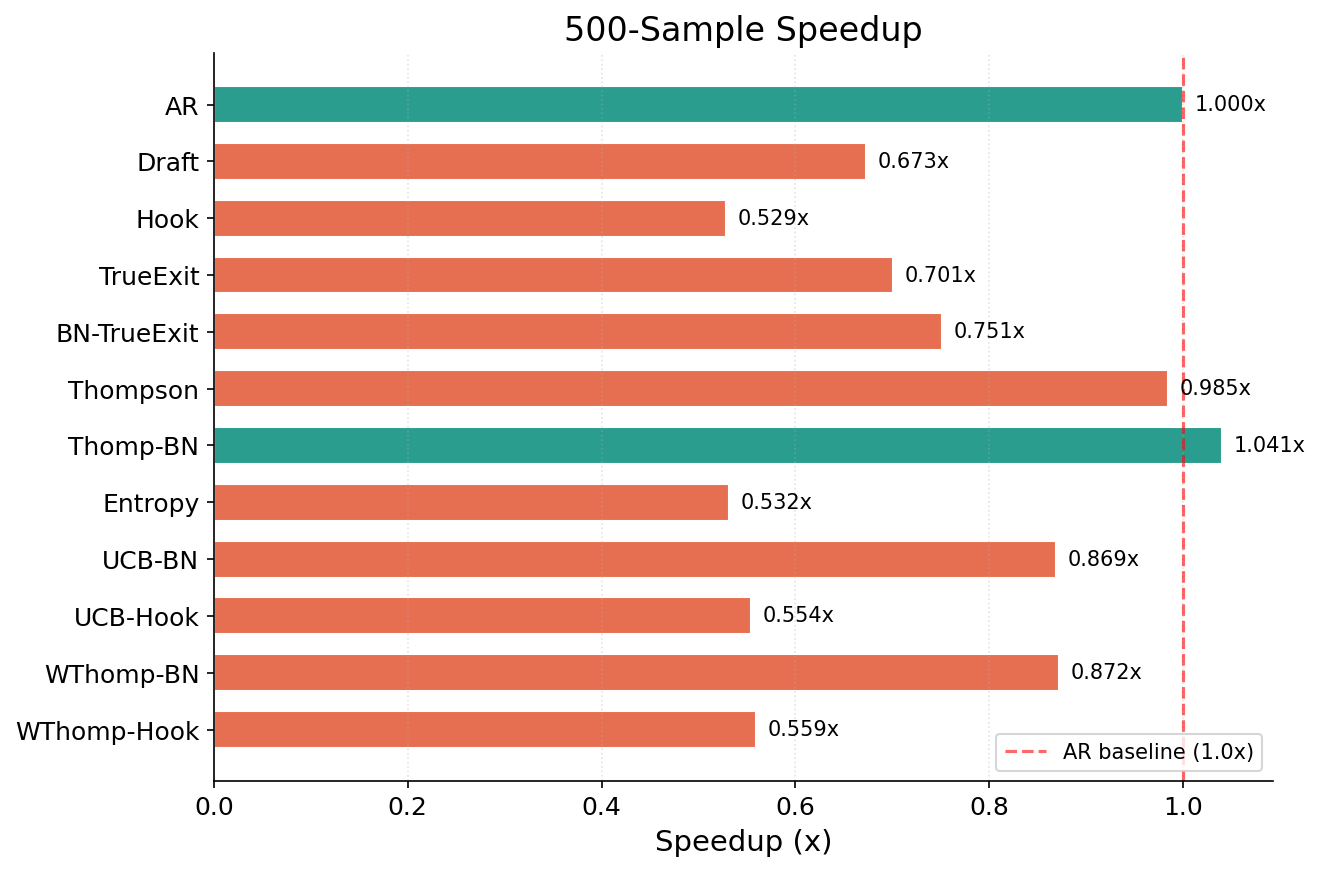

In [131]:
file_500 = Path('outputs_500_prompts/outputs/ablation_results.json')
if not file_500.exists():
    raise FileNotFoundError(f'500-sample results not found: {file_500}')

with file_500.open('r', encoding='utf-8') as f:
    data500 = json.load(f)

methods_500 = [
    k for k in SN
    if k in data500 and isinstance(data500[k], dict) and data500[k].get('method') == k and not data500[k].get('skipped')
]

labels_500 = [SN[k] for k in methods_500]
speedup_500 = [float(data500[k].get('speedup', np.nan)) for k in methods_500]

alpha_methods_500 = [k for k in methods_500 if not pd.isna(data500[k].get('alpha', np.nan))]
alpha_labels_500 = [SN[k] for k in alpha_methods_500]
alpha_500 = [float(data500[k].get('alpha', np.nan)) for k in alpha_methods_500]

# (a) 500-sample acceptance rate as a standalone plot
fig, ax = plt.subplots(figsize=(9, 6))
bars1 = ax.barh(
    alpha_labels_500, alpha_500,
    color=[C.get(k, '#6c757d') for k in alpha_methods_500],
    edgecolor='white', height=0.65
)
for b, a in zip(bars1, alpha_500):
    ax.text(b.get_width() + 0.008, b.get_y() + b.get_height()/2, f'{a:.1%}', va='center', fontsize=10)
ax.set_xlabel('Acceptance Rate (alpha)')
ax.set_title('500-Sample Acceptance Rate')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlim(0, min(1.05, max(alpha_500) + 0.1))
ax.grid(axis='x', linestyle=':', alpha=0.35)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('outputs_AFTER_WT_V6/outputs/fig12_500_sample_acceptance.png', dpi=200, bbox_inches='tight')
plt.show()

# (b) 500-sample speedup as a standalone plot
fig, ax = plt.subplots(figsize=(9, 6))
colors_500 = ['#2a9d8f' if s >= 1.0 else '#e76f51' for s in speedup_500]
bars2 = ax.barh(labels_500, speedup_500, color=colors_500, height=0.65, edgecolor='white')
for b, s in zip(bars2, speedup_500):
    ax.text(b.get_width() + 0.012, b.get_y() + b.get_height()/2, f'{s:.3f}x', va='center', fontsize=10)
ax.axvline(1.0, color='red', ls='--', alpha=0.6, label='AR baseline (1.0x)')
ax.set_xlabel('Speedup (x)')
ax.set_title('500-Sample Speedup')
ax.grid(axis='x', linestyle=':', alpha=0.35)
ax.legend(loc='lower right', fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('outputs_AFTER_WT_V6/outputs/fig12_500_sample_speedup.png', dpi=200, bbox_inches='tight')
plt.show()

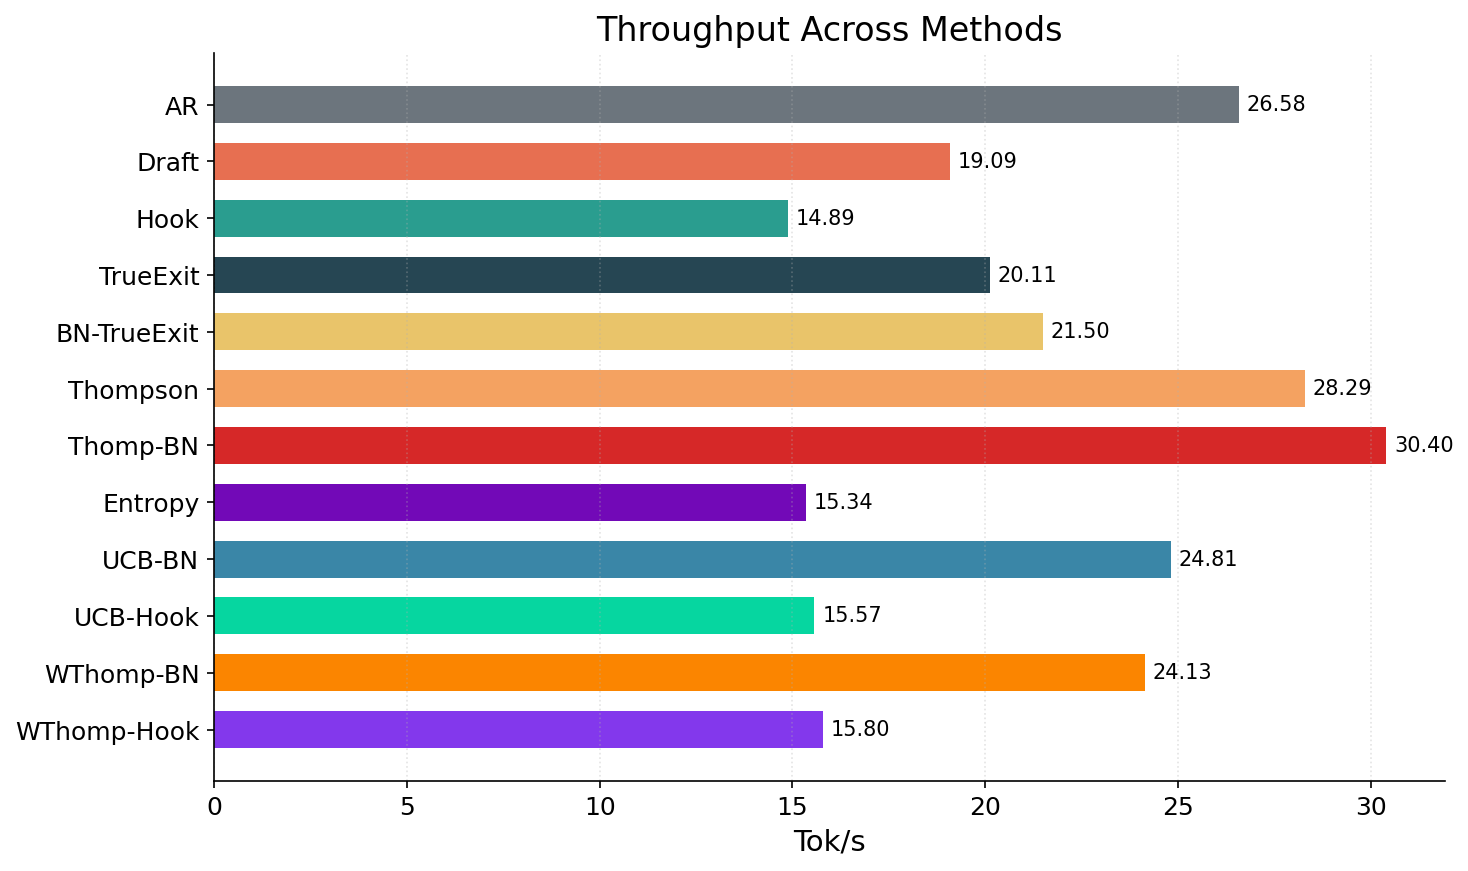

In [132]:
required = ['MK', 'SN', 'data', 'C']
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(f"Missing required variables: {missing}. Run notebook cell 2 first.")

fig, ax = plt.subplots(figsize=(10, 6))
names = [SN[k] for k in MK]
tps_all = [data[k]['tokens_per_sec'] for k in MK]
cols_all = [C[k] for k in MK]

ax.barh(names, tps_all, color=cols_all, height=0.65)
for i, v in enumerate(tps_all):
    ax.text(v + 0.2, i, f'{v:.2f}', va='center', fontsize=10)

ax.set_xlabel('Tok/s')
ax.set_title('Throughput Across Methods')
ax.invert_yaxis()
ax.grid(axis='x', linestyle=':', alpha=0.35)
plt.tight_layout()

# Save in original outputs folder and as a separate final artifact.
plt.savefig('outputs_AFTER_WT_V6/outputs/fig12a_throughput.png', dpi=200, bbox_inches='tight')
Path('results_final/plots').mkdir(parents=True, exist_ok=True)
plt.savefig('results_final/plots/fig12a_throughput_separate.png', dpi=200, bbox_inches='tight')
plt.show()

---
## Summary Table

In [133]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

required = ['MK', 'SN', 'data']
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(f"Missing required variables: {missing}. Run notebook cell 2 first.")

# Ensure 500-sample metrics are available for table columns.
if 'data500' not in globals():
    file_500 = Path('outputs_500_prompts/outputs/ablation_results.json')
    if not file_500.exists():
        raise FileNotFoundError(f'500-sample results not found: {file_500}')
    with file_500.open('r', encoding='utf-8') as f:
        data500 = json.load(f)

rows = []
for k in MK:
    row = {
        'Method': SN[k],
        'α': f"{data[k]['alpha']:.1%}" if 'alpha' in data[k] else '—',
        'Speedup': f"{data[k].get('speedup', 1.0):.3f}×",
        'Tok/s': data[k].get('tokens_per_sec', np.nan),
        '500 Acceptance': (
            f"{data500[k]['alpha']:.1%}"
            if k in data500 and isinstance(data500[k], dict) and 'alpha' in data500[k]
            else '—'
        ),
        '500 Speedup': (
            f"{float(data500[k].get('speedup', np.nan)):.3f}×"
            if k in data500 and isinstance(data500[k], dict) and not pd.isna(data500[k].get('speedup', np.nan))
            else '—'
        ),
    }
    rows.append(row)

df = pd.DataFrame(rows)
df

,Method,α,Speedup,Tok/s,500 Acceptance,500 Speedup
0,AR,—,1.000×,26.58,—,1.000×
1,Draft,65.2%,0.707×,19.09,64.4%,0.673×
2,Hook,46.9%,0.552×,14.89,45.8%,0.529×
3,TrueExit,60.9%,0.736×,20.11,59.7%,0.701×
4,BN-TrueExit,70.9%,0.796×,21.50,68.8%,0.751×
5,Thompson,48.9%,1.054×,28.29,48.4%,0.985×
6,Thomp-BN,54.8%,1.130×,30.40,54.5%,1.041×
7,Entropy,56.5%,0.570×,15.34,55.8%,0.532×
8,UCB-BN,62.3%,0.919×,24.81,60.7%,0.869×
9,UCB-Hook,52.9%,0.578×,15.57,52.0%,0.554×


[INFO] hook_loss.txt not found, using hook_loss_log.txt


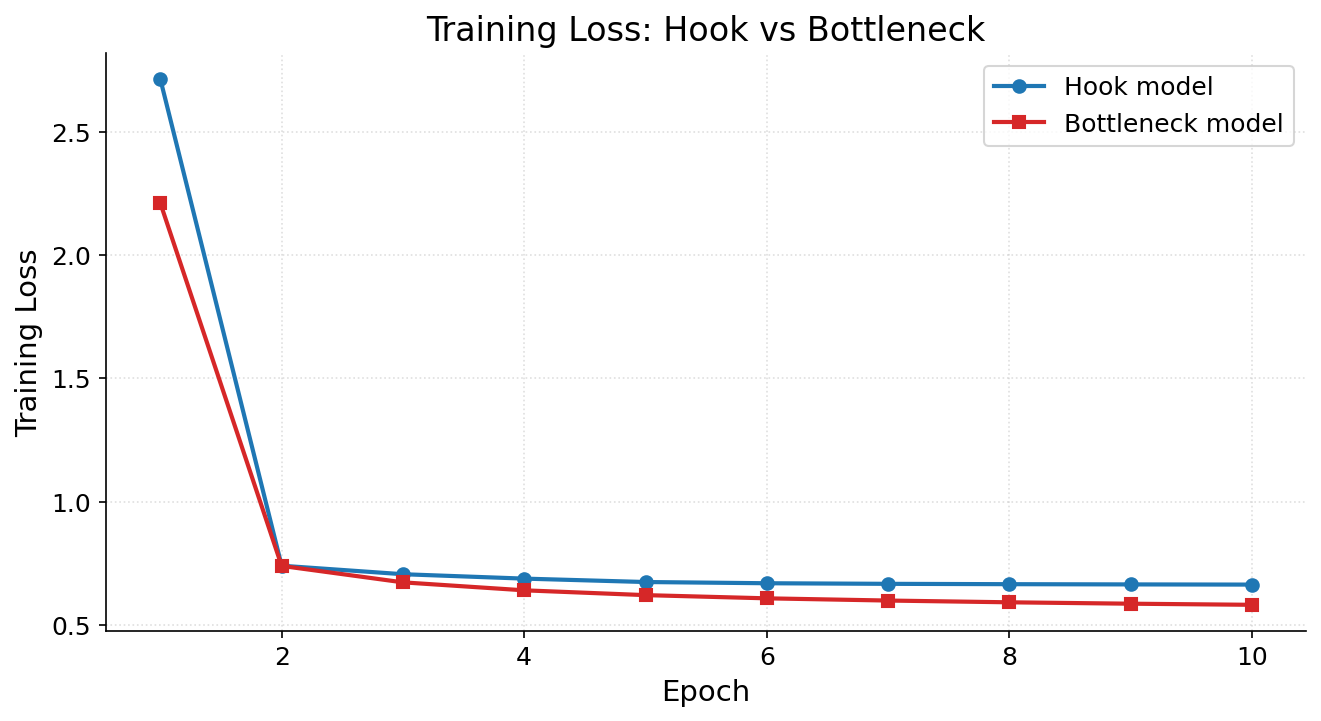

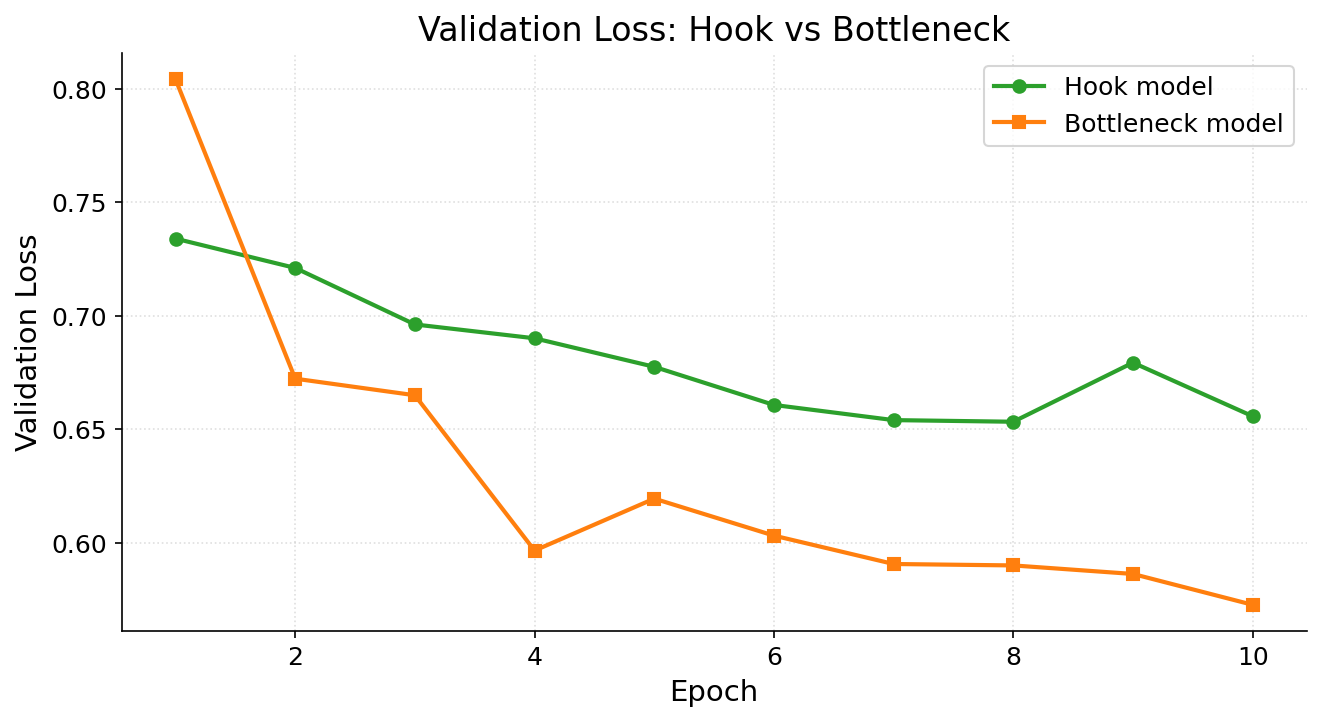

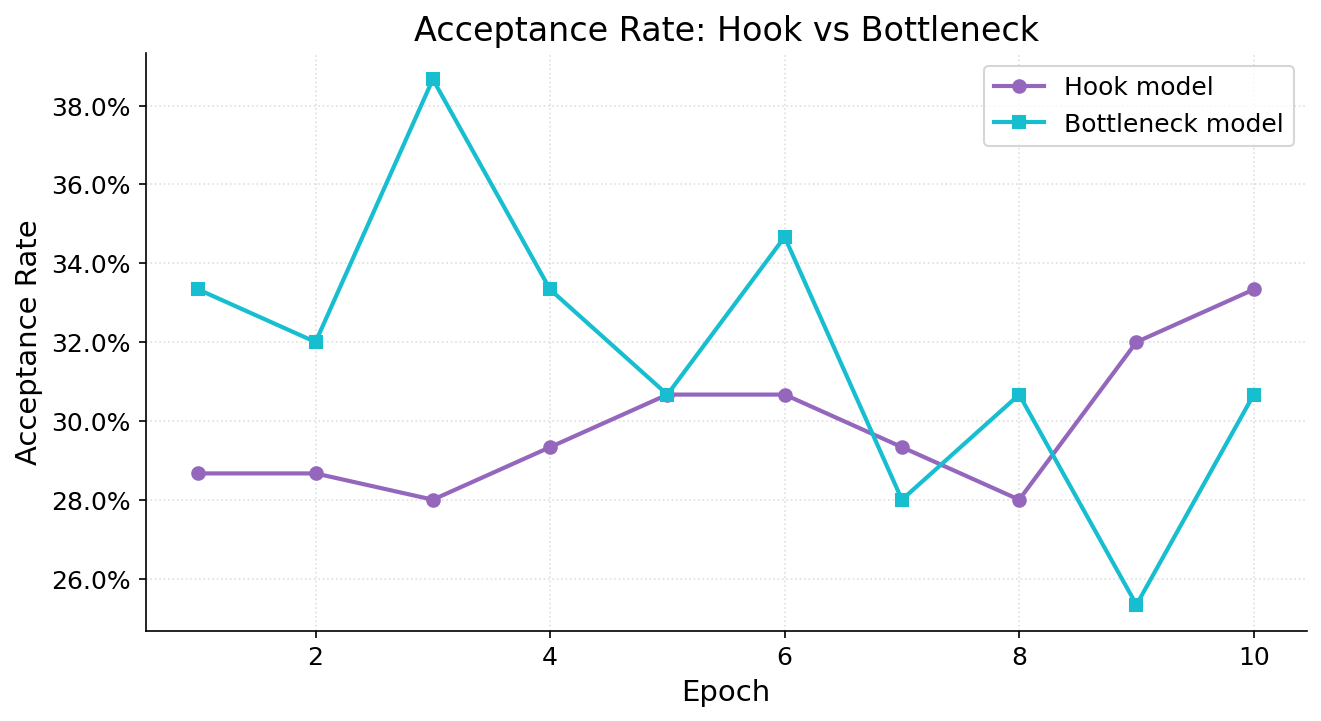

In [134]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

hook_file = Path('/mnt/Shared/INLP_EESD_project/EESD_v3/EESD_v3/logs/hook_loss.txt')
if not hook_file.exists():
    fallback_hook = hook_file.with_name('hook_loss_log.txt')
    if fallback_hook.exists():
        print(f'[INFO] {hook_file.name} not found, using {fallback_hook.name}')
        hook_file = fallback_hook
    else:
        raise FileNotFoundError(f'Hook log not found: {hook_file} (or fallback {fallback_hook})')

bottle_file = Path('/mnt/Shared/INLP_EESD_project/EESD_v3/EESD_v3/logs/bottle_loss_log.txt')
if not bottle_file.exists():
    raise FileNotFoundError(f'Bottle log not found: {bottle_file}')

with hook_file.open('r', encoding='utf-8') as f:
    hook_records = json.load(f)
with bottle_file.open('r', encoding='utf-8') as f:
    bottle_records = json.load(f)

def extract_losses(records):
    epochs = [int(r.get('epoch')) for r in records]
    train = [float(r.get('train_loss', np.nan)) for r in records]
    val = [float(r.get('val_loss', np.nan)) for r in records]
    return epochs, train, val

def extract_acceptance(records):
    acc = []
    for r in records:
        ar = r.get('acceptance_rate', np.nan)
        if isinstance(ar, dict):
            vals = [float(v) for v in ar.values() if isinstance(v, (int, float))]
            acc.append(float(np.mean(vals)) if vals else np.nan)
        elif isinstance(ar, (int, float)):
            acc.append(float(ar))
        else:
            acc.append(np.nan)
    return acc

hook_epochs, hook_train, hook_val = extract_losses(hook_records)
bottle_epochs, bottle_train, bottle_val = extract_losses(bottle_records)
hook_acc = extract_acceptance(hook_records)
bottle_acc = extract_acceptance(bottle_records)

# 1) Training loss comparison
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hook_epochs, hook_train, marker='o', lw=2, color='#1f77b4', label='Hook model')
ax.plot(bottle_epochs, bottle_train, marker='s', lw=2, color='#d62728', label='Bottleneck model')
ax.set_title('Training Loss: Hook vs Bottleneck')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.grid(True, linestyle=':', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

# 2) Validation loss comparison
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hook_epochs, hook_val, marker='o', lw=2, color='#2ca02c', label='Hook model')
ax.plot(bottle_epochs, bottle_val, marker='s', lw=2, color='#ff7f0e', label='Bottleneck model')
ax.set_title('Validation Loss: Hook vs Bottleneck')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.grid(True, linestyle=':', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

# 3) Acceptance rate comparison (mean over depths when per-depth values are present)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hook_epochs, hook_acc, marker='o', lw=2, color='#9467bd', label='Hook model')
ax.plot(bottle_epochs, bottle_acc, marker='s', lw=2, color='#17becf', label='Bottleneck model')
ax.set_title('Acceptance Rate: Hook vs Bottleneck')
ax.set_xlabel('Epoch')
ax.set_ylabel('Acceptance Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.grid(True, linestyle=':', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

In [135]:
from pathlib import Path
import shutil
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

required = ['MK', 'SN', 'data', 'C']
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(f"Missing required variables: {missing}. Run notebook cell 2 first.")

plots_dir = Path('results_final/plots')
tables_dir = Path('results_final/tables')
plots_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

# Remove stale exports so folder contains only latest notebook outputs.
for old_plot in plots_dir.glob('*.png'):
    old_plot.unlink()
for old_table in tables_dir.glob('*.csv'):
    old_table.unlink()

copied_plots = []
copied_plot_names = set()
missing_plots = []

# 1) Copy every figure saved in the main outputs folder.
plot_root = Path('outputs_AFTER_WT_V6/outputs')
source_plots = sorted(plot_root.glob('fig*.png'))
for src in source_plots:
    dst = plots_dir / src.name
    shutil.copy2(src, dst)
    copied_plots.append(dst)
    copied_plot_names.add(dst.name)

# 2) Re-save throughput as an explicit separate plot artifact.
names = [SN[k] for k in MK]
tps_all = [data[k]['tokens_per_sec'] for k in MK]
cols_all = [C[k] for k in MK]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(names, tps_all, color=cols_all, height=0.65)
for i, v in enumerate(tps_all):
    ax.text(v + 0.2, i, f'{v:.2f}', va='center', fontsize=10)
ax.set_xlabel('Tok/s')
ax.set_title('Throughput Across Methods')
ax.invert_yaxis()
ax.grid(axis='x', linestyle=':', alpha=0.35)
plt.tight_layout()
sep_tps_path = plots_dir / 'fig12a_throughput_separate.png'
fig.savefig(sep_tps_path, dpi=200, bbox_inches='tight')
plt.close(fig)
if sep_tps_path.name not in copied_plot_names:
    copied_plots.append(sep_tps_path)
    copied_plot_names.add(sep_tps_path.name)

# 3) Save the plotted figure that did not originally call savefig in its own cell.
required_keys = ['eesd_heavy_hook', 'eesd_heavy_true_exit', 'eesd_bottleneck_true_exit']
if all(k in data for k in required_keys):
    depths = ['8', '16', '22']
    ht = [data['eesd_heavy_hook']['per_depth_time'][d] for d in depths]
    tt = [data['eesd_heavy_true_exit']['per_depth_time'][d] for d in depths]
    bt = [data['eesd_bottleneck_true_exit']['per_depth_time'][d] for d in depths]
    x = np.arange(3)
    w = 0.25

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x - w, ht, w, label='Hook (Heavy)', color='#2a9d8f')
    ax.bar(x, tt, w, label='True Exit (Heavy)', color='#264653')
    ax.bar(x + w, bt, w, label='True Exit (BN)', color='#e9c46a')
    ax.set_ylabel('Time (s)')
    ax.set_title('Per-Depth Total Time')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Depth {d}' for d in depths])
    ax.legend(fontsize=10)
    plt.tight_layout()

    fig11_path = plots_dir / 'fig11_true_exit_vs_hook.png'
    fig.savefig(fig11_path, dpi=200, bbox_inches='tight')
    plt.close(fig)
    if fig11_path.name not in copied_plot_names:
        copied_plots.append(fig11_path)
        copied_plot_names.add(fig11_path.name)

# 4) Save Hook-vs-Bottleneck diagnostics.
hook_file = Path('logs/hook_loss.txt')
if not hook_file.exists():
    fallback_hook = hook_file.with_name('hook_loss_log.txt')
    if fallback_hook.exists():
        hook_file = fallback_hook

bottle_file = Path('logs/bottle_loss_log.txt')
if hook_file.exists() and bottle_file.exists():
    with hook_file.open('r', encoding='utf-8') as f:
        hook_records = json.load(f)
    with bottle_file.open('r', encoding='utf-8') as f:
        bottle_records = json.load(f)

    def _extract_losses(records):
        epochs = [int(r.get('epoch')) for r in records]
        train = [float(r.get('train_loss', np.nan)) for r in records]
        val = [float(r.get('val_loss', np.nan)) for r in records]
        return epochs, train, val

    def _extract_acceptance(records):
        acc = []
        for r in records:
            ar = r.get('acceptance_rate', np.nan)
            if isinstance(ar, dict):
                vals = [float(v) for v in ar.values() if isinstance(v, (int, float))]
                acc.append(float(np.mean(vals)) if vals else np.nan)
            elif isinstance(ar, (int, float)):
                acc.append(float(ar))
            else:
                acc.append(np.nan)
        return acc

    hook_epochs, hook_train, hook_val = _extract_losses(hook_records)
    bottle_epochs, bottle_train, bottle_val = _extract_losses(bottle_records)
    hook_acc = _extract_acceptance(hook_records)
    bottle_acc = _extract_acceptance(bottle_records)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(hook_epochs, hook_train, marker='o', lw=2, color='#1f77b4', label='Hook model')
    ax.plot(bottle_epochs, bottle_train, marker='s', lw=2, color='#d62728', label='Bottleneck model')
    ax.set_title('Training Loss: Hook vs Bottleneck')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Training Loss')
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.legend()
    plt.tight_layout()
    fig13a_path = plots_dir / 'fig13_training_loss_hook_vs_bottleneck.png'
    fig.savefig(fig13a_path, dpi=200, bbox_inches='tight')
    plt.close(fig)
    if fig13a_path.name not in copied_plot_names:
        copied_plots.append(fig13a_path)
        copied_plot_names.add(fig13a_path.name)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(hook_epochs, hook_val, marker='o', lw=2, color='#2ca02c', label='Hook model')
    ax.plot(bottle_epochs, bottle_val, marker='s', lw=2, color='#ff7f0e', label='Bottleneck model')
    ax.set_title('Validation Loss: Hook vs Bottleneck')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation Loss')
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.legend()
    plt.tight_layout()
    fig13b_path = plots_dir / 'fig13_validation_loss_hook_vs_bottleneck.png'
    fig.savefig(fig13b_path, dpi=200, bbox_inches='tight')
    plt.close(fig)
    if fig13b_path.name not in copied_plot_names:
        copied_plots.append(fig13b_path)
        copied_plot_names.add(fig13b_path.name)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(hook_epochs, hook_acc, marker='o', lw=2, color='#9467bd', label='Hook model')
    ax.plot(bottle_epochs, bottle_acc, marker='s', lw=2, color='#17becf', label='Bottleneck model')
    ax.set_title('Acceptance Rate: Hook vs Bottleneck')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Acceptance Rate')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.legend()
    plt.tight_layout()
    fig13c_path = plots_dir / 'fig13_acceptance_rate_hook_vs_bottleneck.png'
    fig.savefig(fig13c_path, dpi=200, bbox_inches='tight')
    plt.close(fig)
    if fig13c_path.name not in copied_plot_names:
        copied_plots.append(fig13c_path)
        copied_plot_names.add(fig13c_path.name)
else:
    missing_plots.append(f'log files missing: hook={hook_file.exists()} bottle={bottle_file.exists()}')

# 5) Export core tables.
exported_tables = []
if 'df' in globals() and isinstance(df, pd.DataFrame):
    csv_path = tables_dir / 'summary_table.csv'
    df.to_csv(csv_path, index=False)
    exported_tables.append(csv_path)
if 'upos_df' in globals() and isinstance(upos_df, pd.DataFrame):
    csv_path = tables_dir / 'morphological_upos_table.csv'
    upos_df.to_csv(csv_path, index=False)
    exported_tables.append(csv_path)

print(f'Plots exported: {len(copied_plots)} -> {plots_dir}')
for p in sorted(copied_plots):
    print(f'  - {p}')
if missing_plots:
    print('Missing expected saved plots (not found at source):')
    for name in missing_plots:
        print(f'  - {name}')

print(f'Tables exported: {len(exported_tables)} -> {tables_dir}')
for t in exported_tables:
    print(f'  - {t}')

Plots exported: 24 -> results_final/plots
  - results_final/plots/fig01_acceptance_rate.png
  - results_final/plots/fig02_speedup.png
  - results_final/plots/fig03_alpha_vs_speedup.png
  - results_final/plots/fig04_vram_usage.png
  - results_final/plots/fig05_depth_heatmap.png
  - results_final/plots/fig06_depth_usage.png
  - results_final/plots/fig06b_depth_usage_stacked.png
  - results_final/plots/fig06c_depth_usage_heatmap_alt.png
  - results_final/plots/fig06d_depth_usage_grouped.png
  - results_final/plots/fig07_k_ablation.png
  - results_final/plots/fig08_latency_breakdown.png
  - results_final/plots/fig09_cross_lingual.png
  - results_final/plots/fig10_morphological.png
  - results_final/plots/fig11_hook_vs_trueexit.png
  - results_final/plots/fig11_true_exit_vs_hook.png
  - results_final/plots/fig12_500_sample_acceptance.png
  - results_final/plots/fig12_500_sample_speedup.png
  - results_final/plots/fig12_500_samples_output.png
  - results_final/plots/fig12_dashboard.png
  - r

---
## Key Findings

1. **Bottleneck True Exit** achieves highest α (70.9%) — better than heavy exit heads (60.9%) and Draft Model (65.2%)
2. **Thompson Bottleneck** achieves real speedup (1.096×) over autoregressive — the only method above 1.0×
3. **Draft Model** uses 2.4× more VRAM than EESD methods (11.1 GB vs ~7.5 GB)
4. **Cross-lingual gap**: Hindi α=61.3% vs English α=15.7% — exit heads trained on Hindi don't transfer
5. **Morphological**: Postpositions easiest (100%), verbs hardest (26.7%), proper nouns difficult (28.6%)
6. **K-ablation**: K=3 is the sweet spot for speedup (0.742×); α drops from K=1 (77.9%) to K=5 (51.2%)